In [1]:
# Cell 1: Import thư viện
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

In [2]:
# Cell 2: Mount Drive (Bỏ qua nếu đã làm)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Cell 3: Đọc dữ liệu
file_path = '/content/drive/MyDrive/Data_InSDN/Cleaned_InSDN_OpenFlow_Dataset.csv'
df = pd.read_csv(file_path)
print(f"Tổng số mẫu: {df.shape[0]}")

Tổng số mẫu: 343889


In [4]:
# Cell 4: Chuẩn bị dữ liệu (Block Split chống Data Leakage)
features = ['duration', 'packet_count', 'byte_count', 'byte_rate', 'packet_rate', 'Protocol']
target = 'Label_Binary'

df_normal = df[df['Label_Binary'] == 0]
df_anomaly = df[df['Label_Binary'] == 1]

X_normal, y_normal = df_normal[features].values, df_normal[target].values
X_anomaly, y_anomaly = df_anomaly[features].values, df_anomaly[target].values

def create_sequences(X, y, seq_length):
    xs, ys = [], []
    for i in range(len(X) - seq_length):
        xs.append(X[i:(i + seq_length)])
        ys.append(y[i + seq_length - 1])
    return np.array(xs), np.array(ys)

seq_length = 10
X_seq_norm, y_seq_norm = create_sequences(X_normal, y_normal, seq_length)
X_seq_anom, y_seq_anom = create_sequences(X_anomaly, y_anomaly, seq_length)

split_norm = int(0.8 * len(X_seq_norm))
split_anom = int(0.8 * len(X_seq_anom))

X_train = np.vstack((X_seq_norm[:split_norm], X_seq_anom[:split_anom]))
y_train = np.concatenate((y_seq_norm[:split_norm], y_seq_anom[:split_anom]))
X_test = np.vstack((X_seq_norm[split_norm:], X_seq_anom[split_anom:]))
y_test = np.concatenate((y_seq_norm[split_norm:], y_seq_anom[split_anom:]))

X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

class SDNDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 256
train_loader = DataLoader(SDNDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(SDNDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)
print("Đã chuẩn bị xong DataLoader cho Transformer!")

Đã chuẩn bị xong DataLoader cho Transformer!


In [5]:
# Cell 5: Xây dựng class Transformer Anomaly
class SDNTransformer(nn.Module):
    def __init__(self, input_size, d_model, nhead, num_layers, seq_length, num_classes=1):
        super(SDNTransformer, self).__init__()

        # 1. Chiếu đầu vào 6 chiều lên không gian lớn hơn (d_model)
        self.input_projection = nn.Linear(input_size, d_model)

        # 2. Positional Encoding (Học vị trí của từng flow trong chuỗi)
        self.pos_encoder = nn.Parameter(torch.randn(1, seq_length, d_model))

        # 3. Lõi Transformer Encoder
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True, dropout=0.2)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)

        # 4. Lớp phân loại cuối cùng
        self.fc = nn.Linear(d_model, num_classes)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Chiếu input và cộng Positional Encoding
        x = self.input_projection(x)
        x = x + self.pos_encoder

        # Đi qua các khối Attention
        x = self.transformer_encoder(x)

        # Lấy thông tin ở bước thời gian cuối cùng để dự đoán
        x = x[:, -1, :]

        out = self.fc(x)
        return self.sigmoid(out)

# Cấu hình siêu tham số
input_size = 6
d_model = 64      # Kích thước không gian Attention
nhead = 4         # Số lượng "đầu" Attention
num_layers = 2    # Số lớp Encoder
seq_length = 10   # Phải khớp với cửa sổ thời gian ở trên

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng phần cứng: {device}")

model_transformer = SDNTransformer(input_size, d_model, nhead, num_layers, seq_length).to(device)
print(model_transformer)

Đang sử dụng phần cứng: cuda
SDNTransformer(
  (input_projection): Linear(in_features=6, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [6]:
# Cell 6: Compile mô hình Transformer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_transformer.parameters(), lr=0.001)

Bắt đầu huấn luyện Transformer...
Epoch [1/15], Loss: 0.0593
Epoch [2/15], Loss: 0.0236
Epoch [3/15], Loss: 0.0195
Epoch [4/15], Loss: 0.0150
Epoch [5/15], Loss: 0.0139
Epoch [6/15], Loss: 0.0123
Epoch [7/15], Loss: 0.0111
Epoch [8/15], Loss: 0.0099
Epoch [9/15], Loss: 0.0091
Epoch [10/15], Loss: 0.0088
Epoch [11/15], Loss: 0.0082
Epoch [12/15], Loss: 0.0076
Epoch [13/15], Loss: 0.0074
Epoch [14/15], Loss: 0.0070
Epoch [15/15], Loss: 0.0066


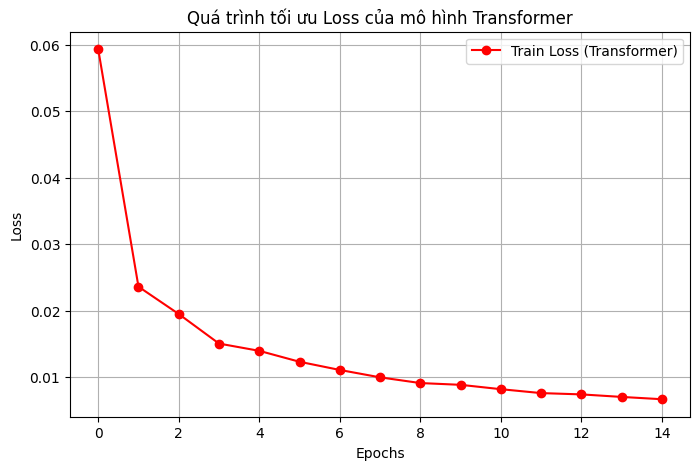

In [7]:
# Cell 7: Huấn luyện Transformer
num_epochs = 15
train_losses = []

print("Bắt đầu huấn luyện Transformer...")
for epoch in range(num_epochs):
    model_transformer.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_transformer(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

# Vẽ đồ thị Loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss (Transformer)', color='red', marker='o')
plt.title('Quá trình tối ưu Loss của mô hình Transformer')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

In [8]:
# Cell 8: Đánh giá hiệu năng Transformer trên tập Test
model_transformer.eval()
all_preds = []
all_labels = []

print("Đang đánh giá mô hình Transformer...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model_transformer(inputs)
        predicted = (outputs > 0.5).float()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n--- BÁO CÁO KẾT QUẢ TRANSFORMER ---")
print(classification_report(all_labels, all_preds, target_names=['Normal (0)', 'Anomaly (1)']))

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
print(f"Accuracy : {acc:.4f}")
print(f"F1-Score : {f1:.4f}")

Đang đánh giá mô hình Transformer...

--- BÁO CÁO KẾT QUẢ TRANSFORMER ---
              precision    recall  f1-score   support

  Normal (0)       0.75      1.00      0.86     13683
 Anomaly (1)       1.00      0.92      0.96     55091

    accuracy                           0.93     68774
   macro avg       0.88      0.96      0.91     68774
weighted avg       0.95      0.93      0.94     68774

Accuracy : 0.9343
F1-Score : 0.9573


In [10]:
# Cell 9: Lưu file .pth
save_path = '/content/drive/MyDrive/Model_InSDN//sdn_transformer_model.pth'
torch.save(model_transformer.state_dict(), save_path)
print(f"Đã lưu mô hình Transformer tại: {save_path}")

Đã lưu mô hình Transformer tại: /content/drive/MyDrive/Model_InSDN//sdn_transformer_model.pth
